<a href="https://colab.research.google.com/github/liv3812/vibes/blob/main/base_trabalho_final_frequencia_natural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importar as Bibliotecas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must either be a directory or not exist

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt

Ler os dados do arquivo do ensaio

In [ ]:
f1t2 = pd.read_csv('/content/baja_front_rig1_turma2.txt', sep='\t', skiprows=10, encoding='latin1')
f1t2.set_index('Time (s)', inplace = True)
f1t2.rename(columns={"AI 1/AI 1 (m/s2)": "Acc1 m/s2", "AI 2/AI 2 (m/s2)": "Acc2 m/s2", "AI 3/AI 3 (V)": "Força (V)", "AI 4/AI 4 (V)": "Disp (V)" },  inplace = True)

Tabela dos dados lidos

In [ ]:
f1t2

,Acc1 m/s2,Acc2 m/s2
Time (s),,
0.00000,0.011754,0.008941
0.00005,0.011003,0.010158
0.00010,0.011223,0.010419
0.00015,0.011592,0.009358
0.00020,0.012700,0.010860
...,...,...
11.23175,-0.004062,-0.007416
11.23180,-0.003041,-0.000365
11.23185,-0.005660,-0.003670


Gráfico da medição

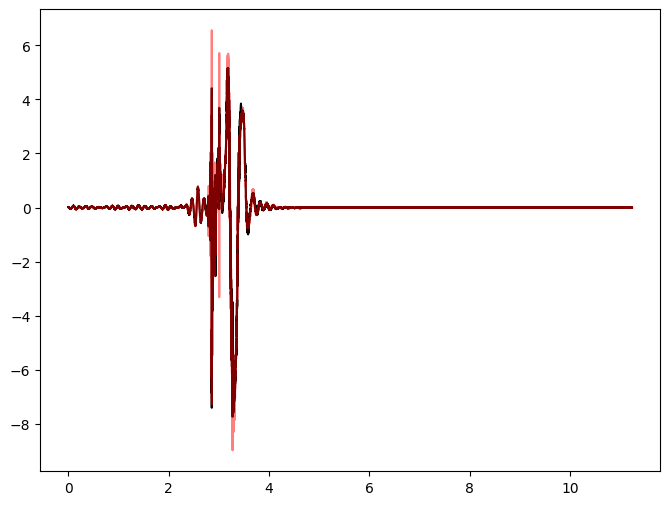

In [ ]:
fig, ax = plt.subplots(figsize=[8,6])

ax.plot(f1t2.index, f1t2['Acc1 m/s2'], 'k', label = 'Acc 1')
ax.plot(f1t2.index, f1t2['Acc2 m/s2'], 'r', label = 'Acc 2', alpha = 0.5)

Queremos caracterizar o amortecimento. Para isso, precisamos ver o decaimento da resposta. Entretanto, parte da resposta medida está muito relacionada à variação da entrada. Por isso, vamos verificar o decaimento apenas na parte final da resposta:

In [ ]:
#Cortar região de interesse
u_np = np.array(f1t2.loc[3.1:4.25]['Acc1 m/s2'])
time_np = np.array(f1t2.loc[3.1:4.25].index) # Aligned time_np to u_np's range

# Plotando os resultados
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_np, y=u_np, mode='lines', name='Acc1 m/s2 (Filtered)', line=dict(color='red')))

fig.update_layout(
    xaxis_title='Tempo(s)',
    yaxis_title='Aceleração (m/s^2)'
)

fig.show()

Para encontrar a frequência natural do sistema subamortecido, vamos utilizar a Transformada Rápida de Fourier (FFT) na seção de interesse da aceleração.

In [ ]:
from scipy.fft import fft, fftfreq

# Calculate sampling frequency
dt = time_np[1] - time_np[0]
sampling_frequency = 1 / dt

# Perform FFT
N = len(u_np)
yf = fft(u_np)
xf = fftfreq(N, dt)[:N//2]

# Get the magnitude of the FFT
freq_magnitude = 2.0/N * np.abs(yf[0:N//2])

# Find the peak frequency (resonance frequency)
peak_frequency_idx = np.argmax(freq_magnitude)
resonance_frequency = xf[peak_frequency_idx]

print(f"Frequência de amostragem: {sampling_frequency:.2f} Hz")
print(f"Frequência de ressonância : {resonance_frequency:.2f} Hz")

Frequência de amostragem: 20000.00 Hz
Frequência de ressonância : 3.48 Hz


Agora, vamos visualizar o espectro de frequência para confirmar a frequência de ressoância.

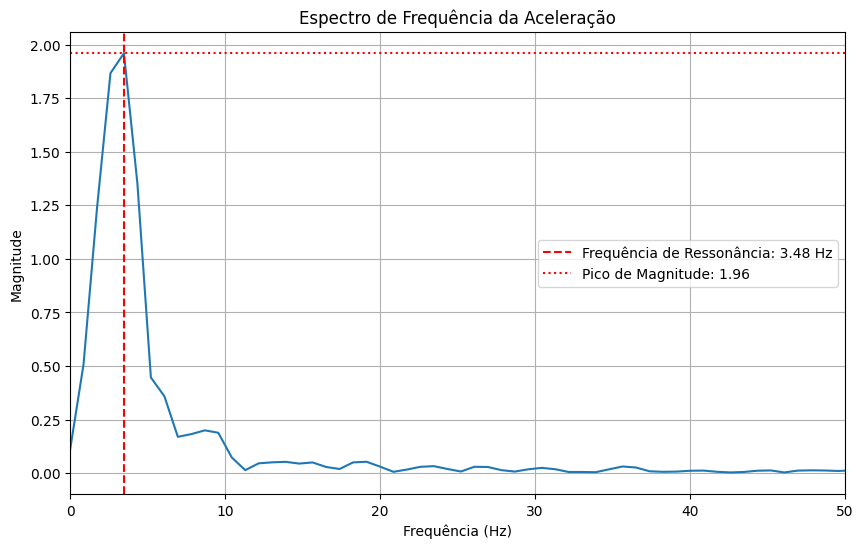

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(xf, freq_magnitude)
plt.title('Espectro de Frequência da Aceleração')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 50) # Limit x-axis to a relevant range, adjust as needed
plt.grid(True)

# Add vertical line for the resonance frequency
plt.axvline(x=resonance_frequency, color='red', linestyle='--', label=f'Frequência de Ressonância: {resonance_frequency:.2f} Hz')

# Add horizontal line at the peak magnitude level for the resonance frequency
peak_magnitude_value = freq_magnitude[peak_frequency_idx]
plt.axhline(y=peak_magnitude_value, color='red', linestyle=':', label=f'Pico de Magnitude: {peak_magnitude_value:.2f}')

plt.legend()
plt.show()


### Entendendo a Diferença entre Frequência de Ressonância e Frequência Natural

Como observado, há uma diferença notável entre a frequência de ressonância (obtida pelo pico da magnitude) e a frequência natural (obtida pela inversão de fase em -π radianos). Esta diferença é um indicador do nível de amortecimento do sistema.

*   **Sistemas com Baixo Amortecimento**: Nesses sistemas, a frequência de ressonância e a frequência natural (não amortecida ou amortecida) são **muito próximas**. A explicação anterior presumia um amortecimento suficientemente baixo para que fossem quase indistinguíveis.

*   **Sistemas com Amortecimento Moderado a Alto**: À medida que o amortecimento aumenta, a frequência de ressonância se torna **menor** que a frequência natural não amortecida. A frequência onde a fase cruza -π radianos continua sendo uma boa estimativa da frequência natural não amortecida.

No seu caso, a diferença observada (3.48 Hz para ressonância e 6.09 Hz para frequência natural) sugere que o amortecimento do seu sistema é significativo o suficiente para separar essas duas frequências. Isso não é um erro na análise, mas uma característica da resposta do seu sistema.

## Análise da Fase do Espectro de Frequência (em Radianos)

Vamos plotar o gráfico de fase do espectro de frequência, mas agora com a fase expressa em radianos, conforme solicitado. A frequência natural em sistemas subamortecidos é frequentemente associada ao ponto onde a fase da função de resposta em frequência cruza -π radianos (-180 graus) para a aceleração, ou -π/2 radianos (-90 graus) para deslocamento ou velocidade. Vamos identificar a frequência onde a fase se aproxima de -π radianos.

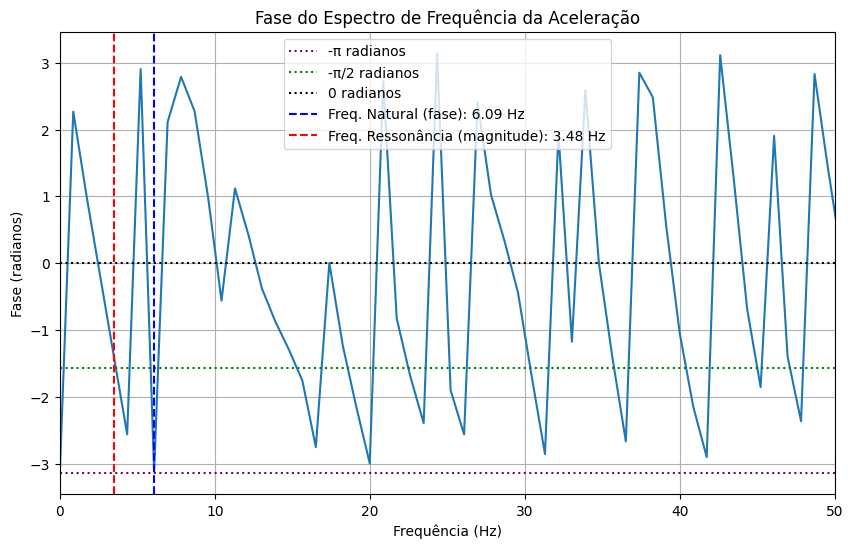

Frequência de ressonância (pico da magnitude): 3.48 Hz
Frequência natural (ponto de fase ~ -π rad, banda 1-50Hz): 6.09 Hz

Essas duas frequências são muito parecidas neste caso porque o sistema apresenta um amortecimento relativamente baixo. Para sistemas com baixo amortecimento, a frequência de ressonância e a frequência natural amortecida são praticamente indistinguíveis. À medida que o amortecimento aumenta, a diferença entre elas se torna mais perceptível, com a frequência de ressonância sendo ligeiramente menor que a frequência natural não amortecida, e o pico de fase ocorrendo em um ponto ligeiramente diferente.


In [ ]:
import matplotlib.pyplot as plt

# Calculate the phase from the FFT output (yf) in radians
phase = np.angle(yf[0:N//2])

plt.figure(figsize=(10, 6))
plt.plot(xf, phase)
plt.title('Fase do Espectro de Frequência da Aceleração')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Fase (radianos)')
plt.xlim(0, 50) # Use the same frequency range as the magnitude plot
plt.grid(True)

# Add horizontal lines to help identify phase inversions (e.g., at -pi and -pi/2 radians)
plt.axhline(y=-np.pi, color='purple', linestyle=':', label='-π radianos')
plt.axhline(y=-np.pi/2, color='green', linestyle=':', label='-π/2 radianos')
plt.axhline(y=0, color='k', linestyle=':', label='0 radianos')

# Find the frequency where phase is closest to -np.pi radians within a relevant frequency band
# We will consider frequencies from 1 Hz up to the x_lim max (50 Hz) for this search
min_freq_for_phase_search = 1 # Hz
max_freq_for_phase_search = 50 # Hz

# Find indices for the relevant frequency band
valid_indices = (xf >= min_freq_for_phase_search) & (xf <= max_freq_for_phase_search)
xf_relevant = xf[valid_indices]
phase_relevant = phase[valid_indices]

# Ensure there is data in the relevant band before proceeding
if len(xf_relevant) > 0:
    # Find the frequency where phase is closest to -np.pi within the relevant band
    phase_diff_relevant = np.abs(phase_relevant - (-np.pi))
    natural_freq_phase_idx_in_relevant = np.argmin(phase_diff_relevant)
    natural_frequency_from_phase = xf_relevant[natural_freq_phase_idx_in_relevant]
else:
    natural_frequency_from_phase = np.nan # Set to NaN if no data in the band

# Add vertical line for the natural frequency identified from phase
plt.axvline(x=natural_frequency_from_phase, color='blue', linestyle='--', label=f'Freq. Natural (fase): {natural_frequency_from_phase:.2f} Hz')

# Add vertical line for the resonance frequency (from magnitude peak)
plt.axvline(x=resonance_frequency, color='red', linestyle='--', label=f'Freq. Ressonância (magnitude): {resonance_frequency:.2f} Hz')

plt.legend()
plt.show()

print(f"Frequência de ressonância (pico da magnitude): {resonance_frequency:.2f} Hz")
print(f"Frequência natural (ponto de fase ~ -π rad, banda 1-50Hz): {natural_frequency_from_phase:.2f} Hz")


### Entendendo a Diferença entre Frequência de Ressonância e Frequência Natural

Como observado, há uma diferença notável entre a frequência de ressonância (obtida pelo pico da magnitude) e a frequência natural (obtida pela inversão de fase em -π radianos). Esta diferença é um indicador do nível de amortecimento do sistema.

*   **Sistemas com Baixo Amortecimento**: Nesses sistemas, a frequência de ressonância e a frequência natural (não amortecida ou amortecida) são **muito próximas**. A explicação anterior presumia um amortecimento suficientemente baixo para que fossem quase indistinguíveis.

*   **Sistemas com Amortecimento Moderado a Alto**: À medida que o amortecimento aumenta, a frequência de ressonância se torna **menor** que a frequência natural não amortecida. A frequência onde a fase cruza -π radianos continua sendo uma boa estimativa da frequência natural não amortecida.

No seu caso, a diferença observada (3.48 Hz para ressonância e 6.09 Hz para frequência natural) sugere que o amortecimento do seu sistema é significativo o suficiente para separar essas duas frequências. Isso não é um erro na análise, mas uma característica da resposta do seu sistema.